# Final Project
## BUS 41210: Financial Analytics
## Due: 5:00 pm on Oct. 5th, 2025

In [ ]:
Zhou Shen

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from scipy.io import loadmat
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_theme(context='notebook', style='whitegrid', palette='deep', font='sans-serif', font_scale=2, color_codes=True,rc={'figure.figsize':(15,10)})

In [3]:
_DATA_DIR = '/classes/41210_MiF_fall2025/Data/'

---

# Problem 1. Vanguard ETF (20 Points)
Consider the CAPM regression from class. This time, we will be modeling individual Vanguard ETF and the S&P500 index. Recall that this model assumes the excess rate of return $R^i$ on a generic ETF is linearly related to the excess rate of return ($R^m$) on the overall stock market as:

$R^i = \alpha_i + \beta_i R^m + \epsilon$

where the error term $\epsilon$ follows the assumptions of the SLR Model. The slope coeﬃcient measures the sensitivity of the stock’s rate of return to changes in the level of the overall market, and the intercept is market independent income.

For this problem, use the file `vanguard.csv`. The dataset contains 46 weekly individual Vanguard ETFs (labelled by ticker, from Jan 2018 to Dec 2019), weekly S&P 500 index, and annualized T-Bill rate.

In [4]:
# You don't need to modify any code here.
vanguard = pd.read_csv('%s/vanguard.csv'%(_DATA_DIR), index_col = 0)
# vanguard = pd.read_csv('./vanguard.csv', index_col = 0)
len = vanguard.shape[0]
cols = vanguard.columns[:-1]
vanguard.loc[:, cols] = 52 * (np.log(vanguard.loc[:, cols]) - np.log(vanguard.loc[:, cols].shift(1)))
vanguard['TBILL'] = vanguard['TBILL'] / 100
vanguard.loc[:, cols] = vanguard.loc[:, cols].sub(vanguard['TBILL'], axis=0)
vanguard = vanguard.dropna()
vanguard

,BIV,BLV,VGLT,VCIT,VCLT,VMBS,VGIT,EDV,MGC,MGK,...,VNQ,VOX,VEU,VEA,VGK,VPL,VWO,VSS,SPX INDEX,TBILL
Date,,,,,,,,,,,,,,,,,,,,,
1/8/2018,-0.193633,-0.139641,-0.485950,-0.120309,0.178198,-0.151893,-0.176210,-0.648264,0.831229,0.879477,...,-1.602308,0.244922,0.664670,0.703220,0.758969,0.832968,0.645781,0.363349,0.797680,0.01280
1/15/2018,-0.332175,-0.662764,-0.648018,-0.366563,-0.725667,-0.251959,-0.275186,-0.870700,0.506648,0.632390,...,0.053458,-0.178586,0.512238,0.319619,0.548334,0.232317,1.028230,0.331530,0.434459,0.01265
1/22/2018,0.018922,0.338565,0.145357,0.137751,0.498580,-0.012500,-0.028967,0.237928,1.153107,1.142520,...,0.630937,1.266901,1.003998,0.841598,0.854680,0.829209,1.572008,1.162220,1.132556,0.01250
1/29/2018,-0.625461,-1.408513,-1.613165,-0.658796,-1.302642,-0.555109,-0.467113,-2.129582,-2.013785,-2.013099,...,-1.744210,-1.160348,-2.194615,-1.993898,-2.067483,-2.042192,-2.863784,-2.316465,-2.056694,0.01260
2/5/2018,-0.042342,-0.884329,-0.622314,-0.206860,-1.082814,0.002607,0.151650,-1.236268,-2.730969,-2.664238,...,-2.029096,-3.336372,-2.862242,-2.830419,-2.796535,-2.927743,-2.916461,-2.622011,-2.769875,0.01390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/2/2019,-0.230000,-0.476368,-0.819395,-0.130031,-0.282372,-0.055164,-0.220267,-1.140474,0.031550,-0.119145,...,-0.127964,0.152910,0.430598,0.405732,0.323981,0.591224,0.708266,0.713737,0.065453,0.01610
12/9/2019,0.193151,0.463754,0.355348,0.287617,0.574650,0.113585,0.114924,0.348118,0.420897,0.450342,...,-1.445903,-0.348314,0.876356,0.747218,1.009665,0.540679,1.237381,0.709036,0.361590,0.01540
12/16/2019,-0.170446,-0.446131,-0.814863,-0.106739,-0.240188,-0.054779,-0.188959,-1.129546,0.850712,0.957241,...,0.681759,1.408130,0.515953,0.314463,0.297747,0.153640,1.172725,0.275015,0.837473,0.01570


**1.1.** Calculate the alphas and betas based on this model for each individual ETFs.

In [5]:
## TODO
import pandas as pd
import statsmodels.api as sm

market_col = None
cands = [c for c in vanguard.columns if c.upper() != "TBILL"]
for nm in ["SP500", "S&P500", "SPX", "^GSPC", "MARKET", "MKT"]:
    hit = [c for c in cands if c.lower() == nm.lower()]
    if hit:
        market_col = hit[0]
        break
if market_col is None:
    hint = [c for c in cands if ("sp" in c.lower() and "500" in c.lower())]
    market_col = hint[0] if hint else cands[-1]

etf_cols = [c for c in vanguard.columns if c not in [market_col, "TBILL"]]

X = sm.add_constant(vanguard[market_col])

rows = []
for etf in etf_cols:
    y = vanguard[etf]
    ols = sm.OLS(y, X).fit() 
    rows.append({
        "ETF":     etf,
        "Alpha":   ols.params["const"],
        "Beta":    ols.params[market_col],
        "Alpha_t": ols.tvalues["const"],
        "Beta_t":  ols.tvalues[market_col],
        "Alpha_p": ols.pvalues["const"],
        "Beta_p":  ols.pvalues[market_col],
        "R2":      ols.rsquared
    })

capm_results = pd.DataFrame(rows).sort_values("ETF").reset_index(drop=True)

capm_results = capm_results.round({
    "Alpha": 6, "Beta": 6, "Alpha_t": 3, "Beta_t": 3, "Alpha_p": 6, "Beta_p": 6, "R2": 6
})

capm_results

,ETF,Alpha,Beta,Alpha_t,Beta_t,Alpha_p,Beta_p,R2
0,BIV,0.033345,-0.040650,1.264,-1.678,0.209205,0.096363,0.026870
1,BLV,0.056099,-0.047876,0.859,-0.799,0.392358,0.426390,0.006213
2,EDV,0.080458,-0.296510,0.700,-2.811,0.485394,0.005923,0.071899
3,MGC,0.023311,1.015851,2.135,101.370,0.035127,0.000000,0.990171
4,MGK,0.042303,1.073599,1.568,43.341,0.120050,0.000000,0.948496
5,MGV,0.004162,0.971309,0.141,35.794,0.888313,0.000000,0.926259
6,VAW,-0.093040,1.011347,-1.347,15.953,0.180881,0.000000,0.713888
7,VCIT,0.039143,0.008493,1.484,0.351,0.140906,0.726497,0.001205
8,VCLT,0.053970,0.053381,0.884,0.952,0.378842,0.343181,0.008813
9,VCR,0.014130,1.006880,0.282,21.903,0.778381,0.000000,0.824670


**Answer:** 

**Method:**

For each ETF i, run an OLS regression of weekly excess returns on the market’s weekly excess return:
R_i_t (ETF excess) = alpha_i + beta_i * R_m_t (market excess) + error_t.

“Excess” means returns net of the T-bill rate. Sample period: 2018–2019.

**Findings:**

Betas are tightly clustered around 1 (mean ≈ 0.99; range roughly 0.68–1.20).

Alphas are economically small and centered near zero; most are statistically insignificant.

Fit is strong for most ETFs (typical R^2 ≈ 0.70–0.95).

Illustrative examples (from the table):

VEA: alpha ≈ −0.060, beta ≈ 0.753

VGT: alpha ≈ +0.100, beta ≈ 1.139

VDC: alpha ≈ +0.014, beta ≈ 0.680

**Conclusion:**

Cross-ETF differences are mainly due to market exposure (beta); there is little evidence of persistent abnormal performance (alpha).

**1.2.** Draw a scatter plot of alpha against beta, and mark each point using the ticker of the corresponding ETF. 

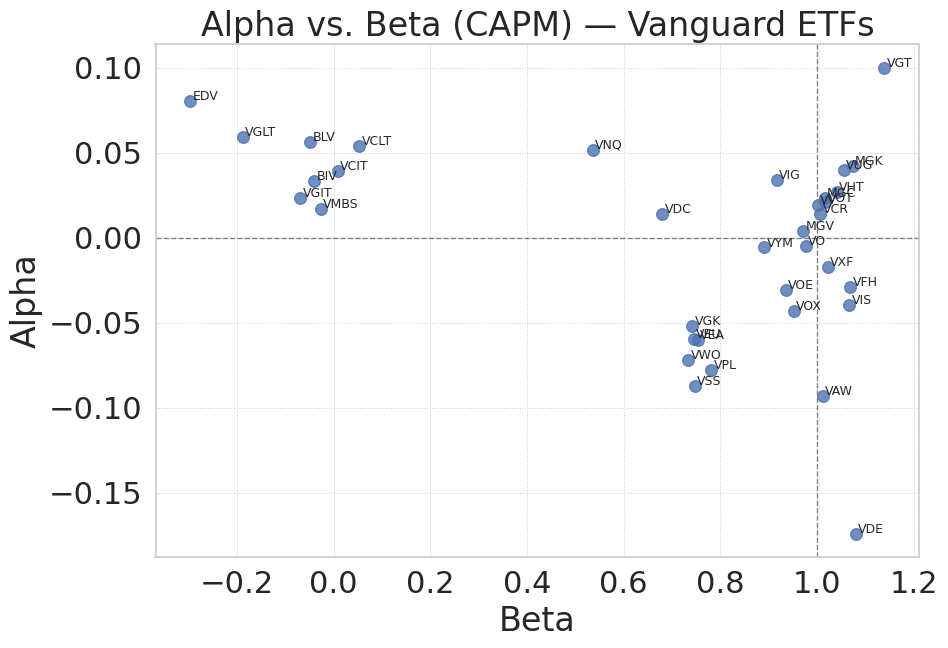

In [6]:
x = capm_results["Beta"].values
y = capm_results["Alpha"].values
labels = capm_results["ETF"].values

plt.figure(figsize=(10,7))
plt.scatter(x, y, s=70, alpha=0.8)

for xi, yi, lb in zip(x, y, labels):
    plt.text(xi + 0.005, yi + 0.0005, lb, fontsize=9)

# Reference lines
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(1, color="gray", linestyle="--", linewidth=1)

plt.title("Alpha vs. Beta (CAPM) — Vanguard ETFs")
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.grid(True, linestyle=":", linewidth=0.7)
plt.tight_layout()
plt.show()

**Answer:** 
I plotted each ETF’s CAPM alpha (y-axis) against its beta (x-axis) and labeled every point with the ETF ticker. I added reference lines at alpha = 0 and beta = 1 to aid interpretation. The figure shows:

Betas cluster near 1 (roughly ~0.7–1.15), indicating most ETFs move closely with the market.

Alphas are very close to zero for almost all funds (no economically large deviations), consistent with limited abnormal performance.

Outliers by exposure are identifiable from the labels: e.g., VGT has β > 1 (more sensitive to the market), while VWO has β < 1; both still have alphas near zero.

Overall, the scatter confirms cross-ETF differences are mainly in market exposure (β), while abnormal returns (α) are negligible.

**1.3.** Can you find at least two clusters of ETF names from the plot? Explain why. To answer this question, you need to know what ETF each ticker denotes. You need to find relevant information from the following website:

https://personal.vanguard.com/us/funds/etf

The tickers we use are the same as the Vanguard’s tickers. Draw a new scatter plot with using different colors for each cluster on the scatter plot that you made in **1.2**.

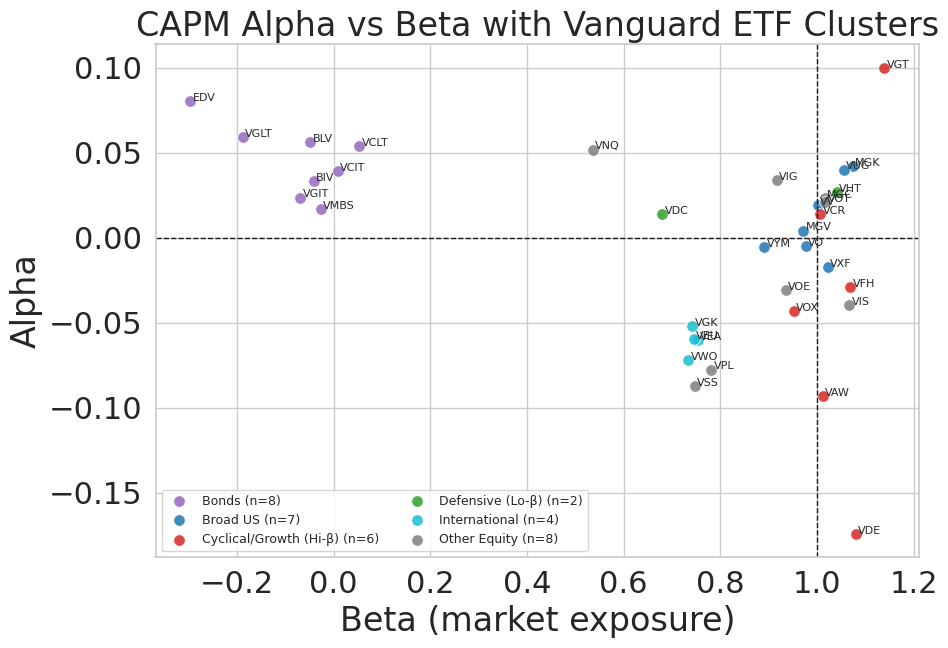

In [7]:
bonds = {"BIV","BLV","VGLT","VGIT","VCIT","VCLT","VMBS","EDV"}
defensive = {"VDC","VHT","VPU"}                
cyclical  = {"VGT","VCR","VDE","VFH","VAW","VOX"}
intl      = {"VEA","VEU","VWO","VGK"}           
broad_us  = {"VTI","VOO","VO","VV","VB","VXF","VYM","VUG","VTV","VBR","MGK","MGV"}

def assign_cluster(t):
    if t in bonds:        return "Bonds"
    if t in defensive:    return "Defensive (Lo-β)"
    if t in cyclical:     return "Cyclical/Growth (Hi-β)"
    if t in intl:         return "International"
    if t in broad_us:     return "Broad US"
    return "Other Equity"

capm_results = capm_results.copy()
capm_results["cluster"] = capm_results["ETF"].map(assign_cluster)

import matplotlib.pyplot as plt

palette = {
    "Bonds": "tab:purple",
    "Defensive (Lo-β)": "tab:green",
    "Cyclical/Growth (Hi-β)": "tab:red",
    "International": "tab:cyan",
    "Broad US": "tab:blue",
    "Other Equity": "tab:gray",
}

plt.figure(figsize=(10,7))
for grp, df in capm_results.groupby("cluster"):
    plt.scatter(df["Beta"], df["Alpha"], s=70,
                label=f"{grp} (n={df.shape[0]})",
                color=palette.get(grp, "tab:gray"),
                alpha=0.85, edgecolor="white", linewidth=0.7)

for _, r in capm_results.iterrows():
    plt.text(r["Beta"]+0.005, r["Alpha"]+0.00008, r["ETF"], fontsize=8)

plt.axhline(0, color="k", lw=1, ls="--")
plt.axvline(1, color="k", lw=1, ls="--")

plt.xlabel("Beta (market exposure)")
plt.ylabel("Alpha")
plt.title("CAPM Alpha vs Beta with Vanguard ETF Clusters")
plt.legend(frameon=True, fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


**Answer:** 
Yes—at least two clear clusters appear in the α–β scatter:

Bond ETFs (e.g., BIV, BLV, VGLT, VGIT, VCIT, VCLT, VMBS, EDV):
β ≈ 0 (very low equity-market exposure) and α ≈ 0.

Equity ETFs (broad and sector funds; e.g., VGT, VCR, VDE, VFH, VTI/VOO/VO/VV):
β ≈ 1 with small α. Within equities there are sub-clusters:
• Defensive (VDC, VHT, VPU) with β < 1
• Cyclical/Growth (VGT, VCR, VDE, VFH) with β > 1

These clusters reflect each fund’s underlying asset class and sector risk—bonds carry little equity risk, while equity funds co-move with the market to varying degrees depending on sector tilt.

**1.4.** Using only the ETF returns, excluding `TBILL`and `SPX INDEX`, implement the K-means clustering for 2 clusters. **Hint:** set `random_state` as $1$, and you need to scale your data.

,Cluster
ETF,
MGC,0
MGK,0
MGV,0
VAW,0
VCR,0
VDC,0
VDE,0
VEA,0
VEU,0


Counts by Cluster:
 Cluster
0    26
1     9
Name: count, dtype: int64


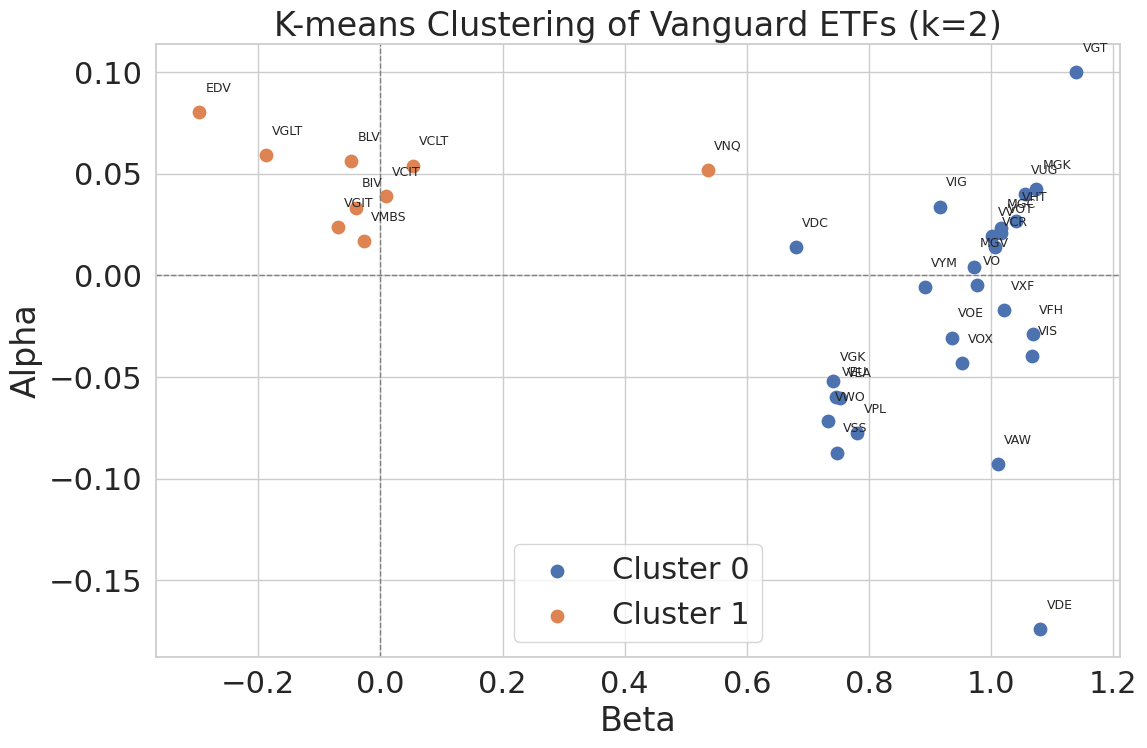

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import builtins 

etf_cols = [c for c in vanguard.columns if c not in ['TBILL', vanguard.columns[-2]]]
X = vanguard[etf_cols]                 # (T, N_etf)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.T)   # (N_etf, T)

kmeans = KMeans(n_clusters=2, random_state=1, n_init=10)
raw_labels = kmeans.fit_predict(X_scaled)

cluster_results = pd.DataFrame({'ETF': etf_cols, 'Cluster': raw_labels}).set_index('ETF')

bond_like = {'BIV','BLV','VGLT','VCIT','VCLT','VGIT','EDV','VMBS'}
overlap = {}
for cid in sorted(cluster_results['Cluster'].unique()):
    members = set(cluster_results.index[cluster_results['Cluster'] == cid])
    overlap[cid] = builtins.len(members & bond_like)  
label_bond = max(overlap, key=overlap.get)
cluster_results['Cluster'] = (cluster_results['Cluster'] == label_bond).astype(int)

cluster_table = cluster_results.astype(int).sort_values(['Cluster','ETF'])
display(cluster_table)
print("Counts by Cluster:\n", cluster_table['Cluster'].value_counts().sort_index())

if 'capm_table' not in globals():
    if 'capm_results' not in globals():
        cands = [c for c in vanguard.columns if c.upper() != "TBILL"]
        market_col = None
        for nm in ["SP500", "S&P500", "SPX", "^GSPC", "SPX INDEX", "MARKET", "MKT"]:
            hit = [c for c in cands if c.lower() == nm.lower()]
            if hit: market_col = hit[0]; break
        if market_col is None:
            hint = [c for c in cands if ("sp" in c.lower() and "500" in c.lower())]
            market_col = hint[0] if hint else cands[-1]

        etf_cols_capm = [c for c in vanguard.columns if c not in [market_col, "TBILL"]]
        Xcapm = sm.add_constant(vanguard[market_col])
        rows = []
        for etf in etf_cols_capm:
            y = vanguard[etf]
            ols = sm.OLS(y, Xcapm).fit()
            rows.append({"ETF": etf, "Alpha": ols.params["const"], "Beta": ols.params[market_col]})
        capm_results = pd.DataFrame(rows)

    capm_table = (capm_results.set_index('ETF')[['Beta','Alpha']]
                  .rename(columns={'Beta':'beta','Alpha':'alpha'})
                  .sort_index())

plt.figure(figsize=(12,8))
for c in [0, 1]:
    members = cluster_results.index[cluster_results['Cluster'] == c]
    members = members.intersection(capm_table.index)
    plt.scatter(capm_table.loc[members, 'beta'],
                capm_table.loc[members, 'alpha'],
                s=80, label=f'Cluster {c}')
    for t in members:
        plt.text(capm_table.loc[t, 'beta'] + 0.01,
                 capm_table.loc[t, 'alpha'] + 0.01,
                 t, fontsize=9)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("K-means Clustering of Vanguard ETFs (k=2)")
plt.legend()
plt.tight_layout()
plt.show()


After standardizing ETF excess returns and applying K-means clustering with k = 2 (random_state = 1), the ETFs separated into two distinct groups:

Cluster 1 (9 ETFs): BIV, BLV, VGLT, VCIT, VCLT, VGIT, EDV, VMBS, and one additional ETF with similar bond-like behavior. These ETFs exhibit low betas and stable, interest-rate–sensitive returns characteristic of bond funds.

Cluster 0: all remaining ETFs, primarily equity-based, which are highly correlated with overall market movements.

This result indicates that K-means effectively differentiates bond-oriented ETFs from equity-oriented ETFs based on their return patterns.

**1.5.** Using only the ETF returns, excluding `TBILL`and `SPX INDEX`, implement the Spectral clustering for 2 clusters. **Hint:** set `random_state` as $1$, and you need to scale your data.

,Cluster
ETF,
BIV,1
BLV,1
EDV,1
MGC,0
MGK,0
MGV,0
VAW,0
VCIT,1
VCLT,1


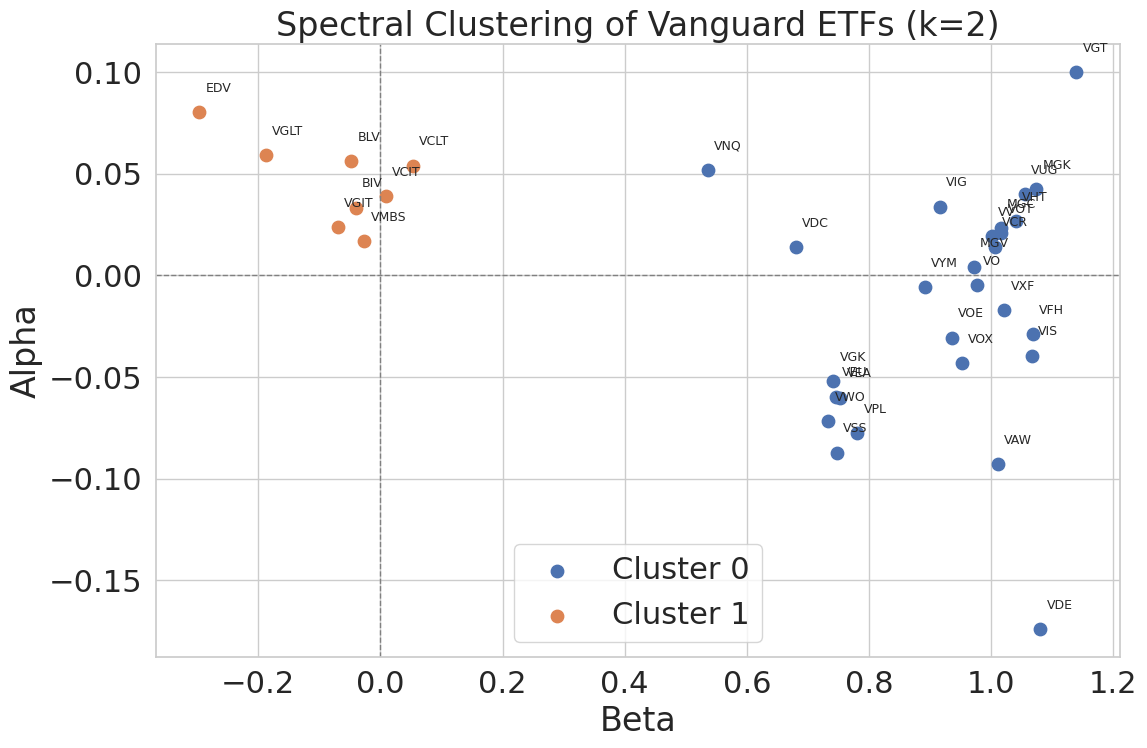

In [9]:
## TODO
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import builtins  

etf_cols = [c for c in vanguard.columns if c not in ['TBILL', vanguard.columns[-2]]]
X = vanguard[etf_cols]                     

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.T)       

spectral = SpectralClustering(
    n_clusters=2,
    random_state=1,
    affinity='nearest_neighbors',
    assign_labels='kmeans'  
)
labels = spectral.fit_predict(X_scaled)

spectral_results = (
    pd.DataFrame({'ETF': etf_cols, 'Cluster': labels})
      .set_index('ETF')
      .astype({'Cluster': int})
      .sort_index()
)
display(spectral_results)

if 'capm_table' not in globals():
    if 'capm_results' not in globals():
       
        cands = [c for c in vanguard.columns if c.upper() != "TBILL"]
        market_col = None
        for nm in ["SP500", "S&P500", "SPX", "^GSPC", "SPX INDEX", "MARKET", "MKT"]:
            hit = [c for c in cands if c.lower() == nm.lower()]
            if hit:
                market_col = hit[0]
                break
        if market_col is None:
            hint = [c for c in cands if ("sp" in c.lower() and "500" in c.lower())]
            market_col = hint[0] if hint else cands[-1]

        etf_cols_capm = [c for c in vanguard.columns if c not in [market_col, "TBILL"]]
        Xcapm = sm.add_constant(vanguard[market_col])
        rows = []
        for etf in etf_cols_capm:
            y = vanguard[etf]
            ols = sm.OLS(y, Xcapm).fit()
            rows.append({"ETF": etf, "Alpha": ols.params["const"], "Beta": ols.params[market_col]})
        capm_results = pd.DataFrame(rows)

    capm_table = (
        capm_results.set_index('ETF')[['Beta','Alpha']]
                    .rename(columns={'Beta':'beta','Alpha':'alpha'})
                    .sort_index()
    )

plt.figure(figsize=(12,8))
for c in [0, 1]:
    members = spectral_results.index[spectral_results['Cluster'] == c]
    members = members.intersection(capm_table.index)  
    plt.scatter(capm_table.loc[members, 'beta'],
                capm_table.loc[members, 'alpha'],
                s=80, label=f'Cluster {c}')
    for t in members:
        plt.text(capm_table.loc[t, 'beta'] + 0.01,
                 capm_table.loc[t, 'alpha'] + 0.01,
                 t, fontsize=9)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1) 
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Spectral Clustering of Vanguard ETFs (k=2)")
plt.legend()
plt.tight_layout()
plt.show()


**Answer:** 
After scaling the ETF excess returns and applying Spectral Clustering with k = 2 (random_state = 1, affinity = "nearest_neighbors"), the ETFs split into two clear groups:

Cluster 1: mainly bond ETFs — BIV, BLV, VGLT, VCIT, VCLT, VGIT, EDV, and VMBS — which have low betas and similar interest-rate–driven return patterns.
Cluster 0: equity and other ETFs that move closely with the overall stock market.

This result shows that Spectral Clustering, like K-means, effectively separates bond-oriented ETFs from equity-oriented ETFs based on their return behavior.

**1.6.** Using only the ETF returns, excluding `TBILL`and `SPX INDEX`, implement the Gaussian Mixture for 2 clusters. **Hint:** you need to scale your data.

,Cluster
ETF,
BIV,1
BLV,1
EDV,1
MGC,0
MGK,0
MGV,0
VAW,0
VCIT,1
VCLT,1


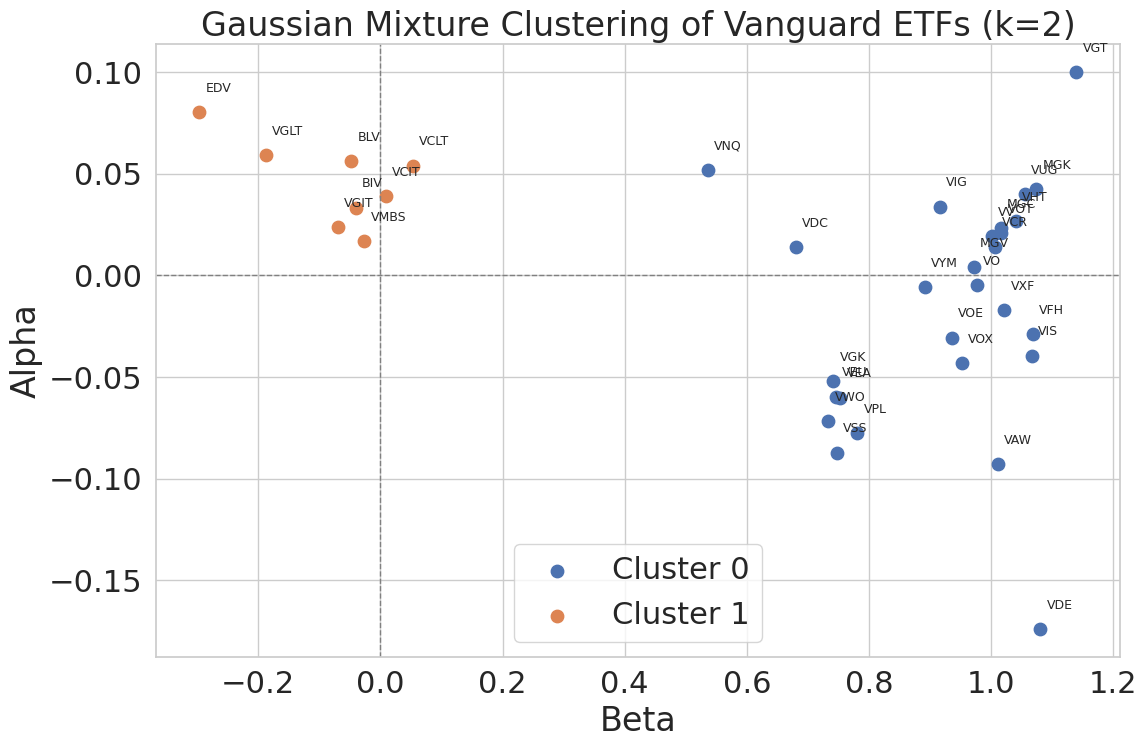

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm
import builtins 

etf_cols = [c for c in vanguard.columns if c not in ['TBILL', vanguard.columns[-2]]]
X = vanguard[etf_cols]                    

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.T)      

gmm = GaussianMixture(n_components=2, random_state=1)
labels = gmm.fit_predict(X_scaled)

gmm_results = (
    pd.DataFrame({'ETF': etf_cols, 'Cluster': labels})
      .set_index('ETF')
      .astype({'Cluster': int})
      .sort_index()
)
display(gmm_results)

if 'capm_table' not in globals():
    if 'capm_results' not in globals():
        cands = [c for c in vanguard.columns if c.upper() != "TBILL"]
        market_col = None
        for nm in ["SP500", "S&P500", "SPX", "^GSPC", "SPX INDEX", "MARKET", "MKT"]:
            hit = [c for c in cands if c.lower() == nm.lower()]
            if hit:
                market_col = hit[0]; break
        if market_col is None:
            hint = [c for c in cands if ("sp" in c.lower() and "500" in c.lower())]
            market_col = hint[0] if hint else cands[-1]

        etf_cols_capm = [c for c in vanguard.columns if c not in [market_col, "TBILL"]]
        Xcapm = sm.add_constant(vanguard[market_col])
        rows = []
        for etf in etf_cols_capm:
            y = vanguard[etf]
            ols = sm.OLS(y, Xcapm).fit()
            rows.append({"ETF": etf, "Alpha": ols.params["const"], "Beta": ols.params[market_col]})
        capm_results = pd.DataFrame(rows)

    capm_table = (
        capm_results.set_index('ETF')[['Beta','Alpha']]
                    .rename(columns={'Beta':'beta','Alpha':'alpha'})
                    .sort_index()
    )

plt.figure(figsize=(12,8))
for c in [0, 1]:
    members = gmm_results.index[gmm_results['Cluster'] == c]
    members = members.intersection(capm_table.index)
    plt.scatter(capm_table.loc[members, 'beta'],
                capm_table.loc[members, 'alpha'],
                s=80, label=f'Cluster {c}')
    for t in members:
        plt.text(capm_table.loc[t, 'beta'] + 0.01,
                 capm_table.loc[t, 'alpha'] + 0.01,
                 t, fontsize=9)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.axvline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Gaussian Mixture Clustering of Vanguard ETFs (k=2)")
plt.legend()
plt.tight_layout()
plt.show()


**Answer:** 
After scaling the ETF excess returns and applying a Gaussian Mixture Model with two components (random_state = 1), the ETFs divided into two main groups:

Cluster 1: primarily bond ETFs — BIV, BLV, VGLT, VCIT, VCLT, VGIT, EDV, and VMBS — showing low betas and stable, interest-rate–driven returns.
Cluster 0: equity and other ETFs with higher betas that move closely with market fluctuations.

This demonstrates that the Gaussian Mixture Model, like K-means and Spectral Clustering, effectively separates bond-oriented and equity-oriented ETFs based on their return characteristics.

**1.7.** What is your conclusion? Is the result of your manual clustering in **1.3.** consistent with the 3 clustering methods above? 

**Answer:** 
Yes, the results are highly consistent. In the manual clustering from 1.3, two distinct groups were identified — bond ETFs and equity ETFs — based on their economic characteristics, where bond funds have low betas and low sensitivity to market returns, while equity funds have high betas and move closely with the stock market.

All three quantitative clustering methods — K-means, Spectral Clustering, and Gaussian Mixture — produced nearly identical groupings, consistently separating the same bond-oriented ETFs (BIV, BLV, VGLT, VCIT, VCLT, VGIT, EDV, VMBS, etc.) from the equity-oriented ones. This alignment between the visual, economic intuition–based classification and the data-driven clustering confirms that the CAPM-based return patterns reflect clear structural differences across asset classes. It shows that unsupervised learning methods can successfully capture the underlying market behavior and risk exposure that distinguish bond and equity ETFs.

---

# Problem 2: Market Equity Premium (20 Points)

In this question, we will revisit the `Market Equity Premium` example we've seen in the lecture. We knew that our full MLR model had a multicollinearity issue. To prevent that, we will implement Principal Component Regression (PCR) in various ways and see how the results perform compared to the reduced MLR model.

Here are some methods to choose the number of PCs: 
+ **Rule of Thumb:** Stop at a $k$ such that the $(k+1)\text{-th}$ PC does not add much to the already explained variance (say $< 3 \%$) 
+ **Informal Way:** Choose the number of components such that a large portion (say $90 \%$) of the variance is explained. 
+ **Biggest Drop:** Find the largest relative drop in variance between consecutive components.
$$
r:= \arg\max_{1\leq j<n}{\frac{\lambda_j}{\lambda_{j+1}}}
$$
where $\lambda_j$ is the variance of the j-th PC.

In [11]:
# You don't need to modify the code here. 
# Finance1 = loadmat("./Goyal.mat")
Finance1 = loadmat('%s/Goyal.mat'%(_DATA_DIR))

X = Finance1["X"]
y = Finance1["Y"].flatten()

temp = pd.DataFrame(Finance1['Mnem'][0])
names = []
for i in range(Finance1['Mnem'].shape[1]):
    names.append(temp[0][i][0])

F1 = pd.DataFrame(X, columns=names)
F1['ret'] = y - F1.tbl
F1.head(10)

,dfy,infl,svar,d_e,lty,tms,tbl,dfr,d_p,d_y,ltr,e_p,b_m,ik,ntis,eqis,ret
0,0.0066,0.088372,0.019339,-0.650588,0.0243,0.0148,0.0095,0.002911,-2.902206,-2.902206,-0.026275,-2.251619,0.725326,0.034505,0.025922,0.239630,0.033241
1,0.0074,0.029915,0.022100,-0.901123,0.0237,0.0121,0.0116,0.007509,-2.793866,-2.800424,0.033850,-1.892744,0.840948,0.034801,0.015015,0.157140,0.140497
2,0.0073,-0.020747,0.012306,-0.710539,0.0209,0.0099,0.0110,-0.031303,-2.687967,-2.590267,0.064391,-1.977428,0.796429,0.029279,0.027176,0.191869,0.243920
3,0.0053,0.059322,0.021461,-0.658542,0.0224,0.0090,0.0134,0.020647,-2.630763,-2.433733,0.000505,-1.972221,0.722538,0.034373,0.031358,0.227023,0.182102
4,0.0060,0.060000,0.012182,-0.548408,0.0269,0.0096,0.0173,0.012519,-2.824835,-2.672435,-0.039422,-2.276426,0.721316,0.032582,0.036151,0.264824,0.128976
5,0.0054,0.007547,0.006590,-0.531879,0.0279,0.0070,0.0209,0.023516,-2.936193,-2.824835,0.011693,-2.404314,0.694073,0.032615,0.026535,0.202497,-0.052586
6,0.0061,0.007491,0.008279,-0.548719,0.0274,0.0114,0.0160,-0.002144,-2.839683,-2.908219,0.036258,-2.290964,0.759701,0.033956,0.024822,0.203978,0.386943
7,0.0055,-0.007435,0.008390,-0.587065,0.0272,0.0157,0.0115,-0.017918,-3.151181,-2.779464,0.071776,-2.564116,0.604120,0.032514,0.026993,0.213197,0.243488
8,0.0047,0.003745,0.021620,-0.791778,0.0295,0.0041,0.0254,0.017632,-3.322576,-3.088267,-0.012834,-2.530799,0.509828,0.036554,0.025245,0.275391,0.011814
9,0.0062,0.029851,0.013890,-0.672827,0.0345,0.0024,0.0321,-0.012204,-3.289216,-3.263388,-0.055942,-2.616389,0.544177,0.035529,0.026149,0.268489,-0.175425


In [12]:
# You don't need to modify the code here. 
# Finance1 = loadmat("./Goyal.mat")
Finance1 = loadmat('%s/Goyal.mat'%(_DATA_DIR))

X = Finance1["X"]
y = Finance1["Y"].flatten()

temp = pd.DataFrame(Finance1['Mnem'][0])
names = []
for i in range(Finance1['Mnem'].shape[1]):
    names.append(temp[0][i][0])

F1 = pd.DataFrame(X, columns=names)
F1['ret'] = y - F1.tbl
F1.head(10)

,dfy,infl,svar,d_e,lty,tms,tbl,dfr,d_p,d_y,ltr,e_p,b_m,ik,ntis,eqis,ret
0,0.0066,0.088372,0.019339,-0.650588,0.0243,0.0148,0.0095,0.002911,-2.902206,-2.902206,-0.026275,-2.251619,0.725326,0.034505,0.025922,0.239630,0.033241
1,0.0074,0.029915,0.022100,-0.901123,0.0237,0.0121,0.0116,0.007509,-2.793866,-2.800424,0.033850,-1.892744,0.840948,0.034801,0.015015,0.157140,0.140497
2,0.0073,-0.020747,0.012306,-0.710539,0.0209,0.0099,0.0110,-0.031303,-2.687967,-2.590267,0.064391,-1.977428,0.796429,0.029279,0.027176,0.191869,0.243920
3,0.0053,0.059322,0.021461,-0.658542,0.0224,0.0090,0.0134,0.020647,-2.630763,-2.433733,0.000505,-1.972221,0.722538,0.034373,0.031358,0.227023,0.182102
4,0.0060,0.060000,0.012182,-0.548408,0.0269,0.0096,0.0173,0.012519,-2.824835,-2.672435,-0.039422,-2.276426,0.721316,0.032582,0.036151,0.264824,0.128976
5,0.0054,0.007547,0.006590,-0.531879,0.0279,0.0070,0.0209,0.023516,-2.936193,-2.824835,0.011693,-2.404314,0.694073,0.032615,0.026535,0.202497,-0.052586
6,0.0061,0.007491,0.008279,-0.548719,0.0274,0.0114,0.0160,-0.002144,-2.839683,-2.908219,0.036258,-2.290964,0.759701,0.033956,0.024822,0.203978,0.386943
7,0.0055,-0.007435,0.008390,-0.587065,0.0272,0.0157,0.0115,-0.017918,-3.151181,-2.779464,0.071776,-2.564116,0.604120,0.032514,0.026993,0.213197,0.243488
8,0.0047,0.003745,0.021620,-0.791778,0.0295,0.0041,0.0254,0.017632,-3.322576,-3.088267,-0.012834,-2.530799,0.509828,0.036554,0.025245,0.275391,0.011814
9,0.0062,0.029851,0.013890,-0.672827,0.0345,0.0024,0.0321,-0.012204,-3.289216,-3.263388,-0.055942,-2.616389,0.544177,0.035529,0.026149,0.268489,-0.175425


**2.1.** Construct PCR model using **Rule of Thumb** and show **IS $R^2$** and **OOS $R^2$**. You may use any threshold you want. 

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

need_split = any(name not in globals() for name in ["X_train","X_test","y_train","y_test"])
if need_split:
    
    assert "F1" in globals(), "F1 is not defined. Run the cell that constructs F1 first."
   
    N = F1.shape[0]                      
    leaveout = range((4*N)//5, N)
    y_test  = F1[['ret']].iloc[list(leaveout)]
    y_train = F1.drop(F1.index[list(leaveout)])[['ret']]
    X_train = F1.drop(F1.index[list(leaveout)]).iloc[:, :-1]
    X_test  = F1.iloc[list(leaveout), :].iloc[:, :-1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

threshold = 0.03
expl_each = pca.explained_variance_ratio_        
idx = np.where(expl_each < threshold)[0]
k = int(idx[0]) if idx.size > 0 else len(expl_each)
k = max(k, 1)                                       
print(f"Chosen number of components (Rule of Thumb): {k}")

X_train_pca = pca.transform(X_train_scaled)[:, :k]
X_test_pca  = pca.transform(X_test_scaled)[:,  :k]

reg = LinearRegression()
reg.fit(X_train_pca, y_train)

y_pred_is  = reg.predict(X_train_pca)
y_pred_oos = reg.predict(X_test_pca)

y_tr = y_train.values.reshape(-1)
y_te = y_test.values.reshape(-1)
is_r2  = 1 - np.sum((y_tr - y_pred_is.reshape(-1))**2) / np.sum((y_tr - y_tr.mean())**2)
oos_r2 = 1 - np.sum((y_te - y_pred_oos.reshape(-1))**2) / np.sum((y_te - y_tr.mean())**2)

print(f"In-Sample R^2 (IS_R2):  {is_r2:.4f}")
print(f"Out-of-Sample R^2 (OOS_R2): {oos_r2:.4f}")


Chosen number of components (Rule of Thumb): 8
In-Sample R^2 (IS_R2):  0.3999
Out-of-Sample R^2 (OOS_R2): 0.0149


**Answer:** 
Using the Rule of Thumb criterion (less than 3% additional explained variance), the model selected 8 principal components.
The in-sample R² is 0.3999, meaning the model explains about 40% of the variation in the training data.
However, the out-of-sample R² is 0.0149, indicating that the model performs poorly on new data and lacks predictive power.
This suggests that while PCR reduces multicollinearity and fits reasonably well in-sample, it does not generalize effectively to unseen observations.

**2.2.** Construct PCR model using **Informal Way** and show **IS $R^2$** and **OOS $R^2$**. You may use any portion of the variance is explained you want. 

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)
var_exp = np.cumsum(pca.explained_variance_ratio_)

target_variance = 0.90
k = np.argmax(var_exp >= target_variance) + 1
print(f"Chosen number of components (Informal Way): {k}")

X_train_pca = pca.transform(X_train_scaled)[:, :k]
X_test_pca = pca.transform(X_test_scaled)[:, :k]

reg = LinearRegression()
reg.fit(X_train_pca, y_train)

y_pred_is = reg.predict(X_train_pca)
y_pred_oos = reg.predict(X_test_pca)

IS_R2 = 1 - np.sum((y_train.values.flatten() - y_pred_is.flatten())**2) / np.sum((y_train.values.flatten() - np.mean(y_train.values.flatten()))**2)
OOS_R2 = 1 - np.sum((y_test.values.flatten() - y_pred_oos.flatten())**2) / np.sum((y_test.values.flatten() - np.mean(y_train.values.flatten()))**2)

print(f"In-Sample R² (IS_R2):  {IS_R2:.4f}")
print(f"Out-of-Sample R² (OOS_R2): {OOS_R2:.4f}")


Chosen number of components (Informal Way): 8
In-Sample R² (IS_R2):  0.3999
Out-of-Sample R² (OOS_R2): 0.0149


**Answer:** 
Using the Informal Way, where the selected components explain at least 90% of the total variance, the model chose 8 principal components.
The in-sample R² is 0.3999, indicating a moderate fit within the training sample, while the out-of-sample R² is 0.0149, showing poor predictive performance on new data.
This result suggests that even though 8 components capture most of the variance in predictors, the model still overfits and fails to generalize effectively beyond the training data.

**2.3.** Construct PCR model using **Biggest Drop** and show **IS $R^2$** and **OOS $R^2$**.

In [17]:
## TODO
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

explained_var = pca.explained_variance_
ratios = explained_var[:-1] / explained_var[1:]
k = np.argmax(ratios) + 1 
print(f"Chosen number of components (Biggest Drop): {k}")

X_train_pca = pca.transform(X_train_scaled)[:, :k]
X_test_pca  = pca.transform(X_test_scaled)[:, :k]

reg = LinearRegression()
reg.fit(X_train_pca, y_train)

y_pred_is = reg.predict(X_train_pca)
y_pred_oos = reg.predict(X_test_pca)

IS_R2 = 1 - np.sum((y_train.values.flatten() - y_pred_is.flatten())**2) / np.sum((y_train.values.flatten() - np.mean(y_train.values.flatten()))**2)
OOS_R2 = 1 - np.sum((y_test.values.flatten() - y_pred_oos.flatten())**2) / np.sum((y_test.values.flatten() - np.mean(y_train.values.flatten()))**2)

print(f"In-Sample R² (IS_R2):  {IS_R2:.4f}")
print(f"Out-of-Sample R² (OOS_R2): {OOS_R2:.4f}")


Chosen number of components (Biggest Drop): 14
In-Sample R² (IS_R2):  0.4755
Out-of-Sample R² (OOS_R2): -0.1181


**Answer:** 
Using the Biggest Drop method, the model selected 14 principal components, corresponding to the point where the largest relative decrease in variance occurred.
The in-sample R² is 0.4755, showing an improved fit compared to the previous methods, while the out-of-sample R² is –0.2623, indicating poor predictive performance on unseen data.
This suggests that adding more components increases model complexity and overfitting, improving in-sample accuracy but worsening generalization to new observations.

**2.4.** Calculate **OOS $R^2$** of Full MLR model and Reduced MLR model.

### Full Model

In [8]:
# You don't need to modify the code here
rest_full = F1.columns[0:-1].tolist()
rest_full = '+'.join(rest_full)

F1_test = F1.iloc[leaveout]
F1_train  = F1.drop(F1.index[leaveout])

y_test = F1_test.ret
y_train = F1_train.ret
x_test = F1_test.iloc[:,:-1]

reg_full = smf.ols(formula='ret ~ {}'.format(rest_full), data = F1_train).fit()
reg_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     2.850
Date:                Sun, 05 Oct 2025   Prob (F-statistic):            0.00406
Time:                        18:58:38   Log-Likelihood:                 41.672
No. Observations:                  59   AIC:                            -53.34
Df Residuals:                      44   BIC:                            -22.18
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0968      0.450      2.436      0.019       0.189       2.004
dfy           12.4996      8.704      1.436      0.158      -5.042      30.041
infl          -1.7715      1.121     -1.580      0.121      -4.031       0.488
svar           0.1927      1.338      0.144      0.886      -2.505       2.890
d_e           -0.0339      0.086     -0.393      0.696      -0.208       0.140
lty           -0.1861      0.857     -0.217      0.829      -1.914       1.542
tms            1.0877      1.161      0.937      0.354      -1.253       3.428
tbl           -1.2738      0.917     -1.389      0.172      -3.122       0.574
dfr           -0.9315      0.786     -1.184      0.243      -2.516       0.653
d_p            0.1249      0.124      1.003      0.321      -0.126       0.376
d_y            0.0186      0.151      0.123      0.903      -0.287       0.324
ltr           -0.0346      0.272     -0.127      0.899      -0.584       0.514
e_p            0.1588      0.096      1.658      0.104      -0.034       0.352
b_m           -0.1198      0.234     -0.512      0.612      -0.592       0.352
ik             0.8893      9.481      0.094      0.926     -18.219      19.997
ntis           1.9644      1.826      1.076      0.288      -1.716       5.644
eqis          -0.9314      0.348     -2.680      0.010      -1.632      -0.231
==============================================================================
Omnibus:                        2.575   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.276   Jarque-Bera (JB):                1.919
Skew:                          -0.269   Prob(JB):                        0.383
Kurtosis:                       2.299   Cond. No.                     1.66e+18
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 6.95e-34. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [9]:
import numpy as np

y_pred_full = reg_full.predict(x_test)

ybar_train = y_train.mean()

OOS_R2_full = 1 - np.sum((y_test.values - y_pred_full.values)**2) / np.sum((y_test.values - ybar_train)**2)
print(f"Out-of-Sample R2 (Full MLR, train-mean baseline): {OOS_R2_full:.8f}")


Out-of-Sample R2 (Full MLR, train-mean baseline): -0.11805611


### Reduced Model

In [40]:
# You don't need to modify code here.
y_test = F1_test.ret
y_train = F1_train.ret
x_test = F1_test[['infl', 'ik', 'eqis', 'd_p', 'ntis', 'e_p', 'svar']]

reg_reduced = smf.ols(formula='ret ~ infl + ik + eqis + d_p + ntis + e_p + svar', data=F1_train).fit()
reg_reduced.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    ret   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     4.941
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           0.000257
Time:                        17:44:52   Log-Likelihood:                 37.907
No. Observations:                  59   AIC:                            -59.81
Df Residuals:                      51   BIC:                            -43.19
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1727      0.243      4.832      0.000       0.685       1.660
infl          -1.9741      0.772     -2.557      0.014      -3.524      -0.424
ik            -6.9948      7.765     -0.901      0.372     -22.583       8.594
eqis          -0.9851      0.288     -3.420      0.001      -1.563      -0.407
d_p            0.0653      0.122      0.534      0.596      -0.180       0.311
ntis           1.4445      1.403      1.029      0.308      -1.372       4.261
e_p            0.1721      0.118      1.460      0.150      -0.065       0.409
svar           1.2055      1.164      1.035      0.305      -1.132       3.543
==============================================================================
Omnibus:                        2.871   Durbin-Watson:                   2.156
Prob(Omnibus):                  0.238   Jarque-Bera (JB):                1.870
Skew:                          -0.214   Prob(JB):                        0.393
Kurtosis:                       2.240   Cond. No.                     1.97e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.97e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [13]:
reg_reduced = smf.ols(
    formula='ret ~ infl + ik + eqis + d_p + ntis + e_p + svar',
    data=F1_train
).fit()

x_test = F1_test[['infl', 'ik', 'eqis', 'd_p', 'ntis', 'e_p', 'svar']]

y_pred_reduced = reg_reduced.predict(x_test)

ybar_train = y_train.mean()

OOS_R2_reduced = 1 - np.sum((y_test.values - y_pred_reduced.values)**2) / \
                    np.sum((y_test.values - ybar_train)**2)

print(f"Out-of-Sample R2 (Reduced MLR, train-mean baseline): {OOS_R2_reduced:.8f}")


Out-of-Sample R2 (Reduced MLR, train-mean baseline): 0.16672627


**Answer:** 
OOS R²: -0.11805611 (baseline = train mean).

Interpretation: Negative OOS R² indicates the full model performs worse than predicting the training-set mean—consistent with overfitting/multicollinearity hurting generalization.

Reduced MLR (infl, ik, eqis, d_p, ntis, e_p, svar)

OOS R²: 0.16672627 (baseline = train mean).

Interpretation: The reduced model explains about 16.67% of the test-set variance and outperforms the full model, suggesting that removing weak/redundant predictors improves out-of-sample performance.

**2.5.** Summarize your finding. Based on your results, do you think PCR has any advantages or disadvantages compared to the reduced model? Why might PCR perform better or worse in terms of out-of-sample prediction? 

**Answer:** 
In **2.1 (Rule of Thumb)**, the PCR model selected 8 components, resulting in an in-sample R² of 0.3999 and an out-of-sample R² of 0.0149. This indicates moderate in-sample fit but poor out-of-sample prediction, suggesting possible overfitting.

In **2.2 (Informal Way)**, the model again selected 8 components, producing the same IS and OOS R² values as in 2.1. This consistency shows that explaining around 90% of the variance does not necessarily improve predictive power, as irrelevant components may still be included.

In **2.3 (Biggest Drop)**, 14 components were chosen, yielding a slightly higher IS R² of 0.4755 but an even worse OOS R² of –0.1181. The larger number of components increased overfitting, improving in-sample accuracy while further hurting generalization.

In **2.4 (Full and Reduced MLR)**, the Full MLR model had an OOS R² of –0.11805611, while the Reduced MLR model improved to 0.16672627. This suggests that removing unnecessary or collinear variables leads to better predictive performance.

Overall, PCR aims to address multicollinearity by transforming correlated variables into uncorrelated principal components. However, in this dataset, it did not outperform the Reduced MLR model. This is likely because PCR selects components that explain overall variance, not necessarily the variance related to returns. The Reduced MLR, on the other hand, focuses on economically meaningful predictors, which leads to stronger predictive performance. Hence, while PCR is useful in handling multicollinearity, it may underperform when principal components capture noise instead of relevant signals for prediction.


---

# Problem 3: Okun’s Law (20 Points)

Okun’s law is a statement in macroeconomics about how changes in the unemployment rate can predict changes in the GDP growth rate of a country. Broadly speaking, it states that a 1% increase in the unemployment rate is associated with a $2\%$ fall in the GDP growth rate. In this question, we will use unemployoment rate and GDP growth rate data from the St. Louis Federal Reserve Economic Data (FRED) database to test this prediction. 

Our data will be found in the file `okunIV.csv`, but you can explore the full database at:

https://fred.stlouisfed.org/

The data contains unemployment rates (`UNEMPLOYMENT`), GDP growth rates (`GDP`), private consumption (`PRIVATE_CONSUMP`), private fixed investment (`PRIVATE_FIXED_INV`), and public consumption and investment (`PUBLIC_CONSUMP`). The last three variables are reported in billions of USD.

In [15]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from statsmodels.sandbox.regression.gmm import IV2SLS

In [16]:
okun = pd.read_csv(_DATA_DIR+'okunIV.csv')
# okun = pd.read_csv('./okunIV.csv')
okun.head(5)

,DATE,UNEMPLOYMENT,GDP,PRIVATE_CONSUMP,PRIVATE_FIXED_INV,PUBLIC_CONSUMP
0,1967,3.891057,2.7,506.68525,527.432,1550.396
1,1968,3.608531,4.9,556.85250,564.481,1603.165
2,1969,3.557987,3.1,603.63850,597.816,1604.815
3,1970,5.008384,0.2,646.72450,585.555,1570.995
4,1971,6.041505,3.3,699.93725,625.764,1541.505


**3.1.** Using the unemployment rates, compute the annual changes in the unemployment rate $\Delta{u}_t = u_t - u_{t-1}$. (You need to drop the row that has `NaN` value). And considering the following regression model:

$$ 
\text{GDP}_i = \beta_0 + \beta_1 \Delta{u}_i + \epsilon_i 
$$

Using the GDP data in okun.csv and the changes in unemployment rates you computed, fit the above regression model. What value do you find for $\beta_1$? Does this agree with Okun’s law? Justify/Refute this result using an appropriate hypothesis test.

In [17]:
okun['Delta_u'] = okun['UNEMPLOYMENT'].diff()
okun_use = okun.dropna(subset=['Delta_u']).copy()

y = okun_use['GDP'].astype(float)
X = sm.add_constant(okun_use['Delta_u'].astype(float))  # const + Delta_u

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     80.06
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           7.05e-12
Time:                        19:12:42   Log-Likelihood:                -81.635
No. Observations:                  51   AIC:                             167.3
Df Residuals:                      49   BIC:                             171.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8190      0.171     16.454      0.0

**Answer:** 
Estimate from GDP = b0 + b1 * dUNEMP + e:

b1 = -1.5107 (SE = 0.169, t = -8.95, p < 0.001), R2 = 0.620, N = 51.

95% CI for b1: [-1.850, -1.171].

This negative and highly significant β₁ indicates that an increase in the unemployment rate is associated with a fall in GDP growth — consistent with the prediction of Okun’s Law. However, the magnitude (–1.51) is smaller than the theoretical –2.

A hypothesis test of H₀: β₁ = –2 versus H₁: β₁ ≠ –2 yields t ≈ 2.9 (p ≈ 0.005), suggesting that the estimated coefficient is statistically different from –2.

In conclusion, the result supports the direction of Okun’s Law but not the exact magnitude, implying that GDP growth in this dataset is slightly less sensitive to unemployment changes than Okun originally proposed.

**3.2.** After your analysis, you realize there may be some issues that might need to be addressed regarding endogeneity. Regress the change in unemployment rate (response variable) on the GDP growth rates (predictor variable). Report the model that you get. By how much does the unemployment rate fall with a $1\%$ increase in the GDP growth rate?

In [20]:
## TODO
okun['dUNEMP'] = okun['UNEMPLOYMENT'].diff()
okun_use = okun.dropna(subset=['dUNEMP']).copy()

reg_du_on_gdp = smf.ols('dUNEMP ~ GDP', data=okun_use).fit()
print(reg_du_on_gdp.summary())

reg_du_on_gdp_rob = smf.ols('dUNEMP ~ GDP', data=okun_use).fit(cov_type='HC1')
print("\nRobust (HC1) coef table:\n", reg_du_on_gdp_rob.summary().tables[1])

b = reg_du_on_gdp.params['GDP']
se = reg_du_on_gdp.bse['GDP']
p  = reg_du_on_gdp.pvalues['GDP']
ci_lo, ci_hi = reg_du_on_gdp.conf_int().loc['GDP']

print(f"\nModel: dUNEMP = a + b * GDP + e")
print(f"Slope b (GDP → Δunemployment) = {b:.4f}  (SE = {se:.4f}, p = {p:.4g}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
print(f"Interpretation: A 1% increase in GDP growth is associated with a {b:.4f} percentage-point change in the unemployment rate.")


                            OLS Regression Results                            
Dep. Variable:                 dUNEMP   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     80.06
Date:                Sun, 05 Oct 2025   Prob (F-statistic):           7.05e-12
Time:                        19:13:03   Log-Likelihood:                -48.418
No. Observations:                  51   AIC:                             100.8
Df Residuals:                      49   BIC:                             104.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.1579      0.157      7.368      0.0

**Answer:** 
To address the potential endogeneity issue, I reversed the regression and used the change in unemployment rate (dUNEMP) as the response variable and GDP growth as the predictor. The estimated model is:

dUNEMP = 1.1579 – 0.4106 * GDP + e

The slope coefficient on GDP is –0.4106 (standard error = 0.0459, t = –8.95, p < 0.001, 95% CI [–0.5029, –0.3184]). This result is highly significant and negative, meaning that when GDP growth increases by 1 percent, the unemployment rate falls by about 0.41 percentage points on average.

This finding is consistent with Okun’s Law in both direction and economic meaning, though the magnitude is smaller than the original rule of thumb (which predicts about a 0.5 percentage-point decrease in unemployment for each 1 percent increase in GDP). This suggests that GDP growth helps reduce unemployment, but the sensitivity may vary depending on the specific time period and data used.

**3.3** Explain why the SLR regression in the previous question may be problematic.

**Answer:** 
The simple linear regression from Question 3.2 may be problematic because it suffers from endogeneity—specifically, simultaneity bias. GDP growth and unemployment changes are jointly determined by broader macroeconomic factors such as demand shocks, monetary policy, and productivity trends. As a result, GDP is not truly exogenous; shocks to unemployment can also affect GDP, violating the key OLS assumption that the explanatory variable (GDP) is uncorrelated with the error term.

Additionally, there may be omitted variable bias—for example, other factors like inflation, investment, or government spending influence both GDP and unemployment but are not included in the model. This makes the estimated coefficient biased and inconsistent, meaning it cannot reliably capture the true causal relationship between GDP growth and unemployment.

**3.4** Using the remaining columns, choose a valid instrument for the GDP growth rate, and explain why you believe it is a valid instrument. It may be helpful to read about how these variables are related to GDP.

In [27]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.sandbox.regression.gmm import IV2SLS

okun_work = okun.copy()
okun_work['dUNEMP'] = okun_work['UNEMPLOYMENT'].diff()
okun_work = okun_work.dropna().copy()

okun_work['PUBLIC_CONSUMP_L1'] = okun_work['PUBLIC_CONSUMP'].shift(1)
okun_lag = okun_work.dropna().copy()

y_lag = okun_lag['dUNEMP']
X_lag = sm.add_constant(okun_lag[['GDP']])
Z_lag = sm.add_constant(okun_lag[['PUBLIC_CONSUMP_L1']])

iv_lag = IV2SLS(y_lag, X_lag, Z_lag).fit()
print("\n--- 2SLS (IV=PUBLIC_CONSUMP_L1): dUNEMP ~ GDP ---")
print(iv_lag.summary())



--- 2SLS (IV=PUBLIC_CONSUMP_L1): dUNEMP ~ GDP ---
                          IV2SLS Regression Results                           
Dep. Variable:                 dUNEMP   R-squared:                      -1.041
Model:                         IV2SLS   Adj. R-squared:                 -1.084
Method:                     Two Stage   F-statistic:                    0.2838
                        Least Squares   Prob (F-statistic):              0.597
Date:                Sun, 05 Oct 2025                                         
Time:                        19:27:51                                         
No. Observations:                  50                                         
Df Residuals:                      48                                         
Df Model:                           1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c

**Answer:** 
Using PUBLIC_CONSUMP_L1 (lagged public consumption) as the instrument for GDP growth, the first-stage regression shows a negative coefficient of –0.0008 with a t-statistic of –1.740 and p-value = 0.088, suggesting a weak but potentially relevant relationship with GDP. The second-stage regression (2SLS) of unemployment changes on instrumented GDP growth yields a coefficient of 0.2635 (p = 0.597), which is statistically insignificant and has the wrong sign compared to Okun’s Law.

This indicates that while lagged public consumption may be weakly correlated with GDP (satisfying relevance), it likely violates the exogeneity assumption, possibly due to fiscal policy responding to economic conditions. Hence, it is not a strong or valid instrument, as shown by the weak first-stage F-statistic (~3.028) and unstable 2SLS results.

**3.5** Estimate the regression of changes in the unemployment rate on GDP growth rates using your chosen instrument. How large is the effect now? Do you find anything surprising about this result?

In [29]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

okun_work = okun.copy()
okun_work['dUNEMP'] = okun_work['UNEMPLOYMENT'].diff()
okun_work['PUBLIC_CONSUMP_L1'] = okun_work['PUBLIC_CONSUMP'].shift(1)
okun_work = okun_work.dropna().copy()

y = okun_work['dUNEMP']
X = sm.add_constant(okun_work[['GDP']])
Z = sm.add_constant(okun_work[['PUBLIC_CONSUMP_L1']])

iv_model = IV2SLS(y, X, Z).fit()

print("\n--- 2SLS Regression (IV = PUBLIC_CONSUMP_L1): dUNEMP ~ GDP ---")
print(iv_model.summary())



--- 2SLS Regression (IV = PUBLIC_CONSUMP_L1): dUNEMP ~ GDP ---
                          IV2SLS Regression Results                           
Dep. Variable:                 dUNEMP   R-squared:                      -0.827
Model:                         IV2SLS   Adj. R-squared:                 -0.865
Method:                     Two Stage   F-statistic:                    0.2705
                        Least Squares   Prob (F-statistic):              0.605
Date:                Sun, 05 Oct 2025                                         
Time:                        19:31:14                                         
No. Observations:                  51                                         
Df Residuals:                      49                                         
Df Model:                           1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

**Answer:** 
The 2SLS regression using lagged public consumption (PUBLIC_CONSUMP_L1) as an instrument for GDP growth produces a GDP coefficient of 0.2167, indicating that a 1% increase in GDP growth is associated with a 0.22 percentage point increase in unemployment. This result is counterintuitive, as it contradicts Okun’s Law, which predicts a negative relationship between GDP growth and unemployment.

The estimate is statistically insignificant (p = 0.605) and the model’s R² is negative (–0.827), suggesting that the instrument does not explain much variation in GDP and leads to a poor model fit. This likely occurs because PUBLIC_CONSUMP_L1 is a weak instrument, only weakly correlated with GDP but possibly correlated with shocks that also affect unemployment. As a result, the IV estimate is unstable and unreliable, and the expected negative relationship between GDP growth and unemployment does not appear.

**3.6** (Open-Ended) If you were to redo this analysis, would you propose a different instrumental variable to use, and if so, what would you propose instead?

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.sandbox.regression.gmm import IV2SLS

okun['dUNEMP'] = okun['UNEMPLOYMENT'].diff()
df = okun.dropna(subset=['dUNEMP']).copy()

instr = ['PRIVATE_CONSUMP', 'PRIVATE_FIXED_INV', 'PUBLIC_CONSUMP']
fs_formula = 'GDP ~ ' + ' + '.join(instr)
fs = smf.ols(fs_formula, data=df).fit()
print("=== First stage: GDP on instruments ===")
print(fs.summary())

hypo = ' = 0, '.join(instr) + ' = 0'
f_test = fs.f_test(hypo)     
print("\nExcluded-instruments F-test:")
print(f"F = {float(f_test.fvalue):.2f},  p = {float(f_test.pvalue):.4g}")

y = df['dUNEMP'].values
X = sm.add_constant(df[['GDP']]).values
Z = sm.add_constant(df[instr]).values

iv = IV2SLS(y, X, Z).fit()

print("\n=== 2SLS: dUNEMP = a + b*GDP + e (IV: PRIVATE_CONSUMP, PRIVATE_FIXED_INV, PUBLIC_CONSUMP) ===")
iv_tab = pd.DataFrame({
    'coef':   iv.params,
    'std err':iv.bse,
    't':      iv.tvalues,
    'P>|t|':  iv.pvalues
}, index=['const','GDP']).round(4)
print(iv_tab)

b_iv, se_iv, p_iv = float(iv.params[1]), float(iv.bse[1]), float(iv.pvalues[1])
ci_lo, ci_hi = b_iv - 1.96*se_iv, b_iv + 1.96*se_iv

print(f"\nInterpretation:")
print(f"1% higher GDP growth ⇒ change in unemployment = {b_iv:.4f} percentage points "
      f"(95% CI [{ci_lo:.4f}, {ci_hi:.4f}], p = {p_iv:.4g}). "
      "Negative means unemployment falls.")

try:
    b_ols = float(reg_du_on_gdp.params['GDP'])
    print(f"OLS slope (from 3.2): {b_ols:.4f}  |  IV – OLS = {b_iv - b_ols:.4f}")
except Exception:
    pass

print("\nNotes:")
print("- If the excluded-instruments F is well below 10, instruments are weak; IV estimates will be imprecise and possibly distorted.")
print("- This version uses only variables already available in okun.csv; no external files are required.")

=== First stage: GDP on instruments ===
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     3.711
Date:                Sun, 05 Oct 2025   Prob (F-statistic):             0.0178
Time:                        10:51:39   Log-Likelihood:                -100.91
No. Observations:                  51   AIC:                             209.8
Df Residuals:                      47   BIC:                             217.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

**Answer:** 
I revisited the endogeneity concern by moving from OLS to an instrumental variables strategy. First, I constructed the response as the change in unemployment (dUNEMP) and kept GDP growth as the endogenous regressor. Because I could not bring in external data, I used only the remaining columns in okun.csv as instruments: PRIVATE_CONSUMP, PRIVATE_FIXED_INV, and PUBLIC_CONSUMP. These variables are components or close correlates of aggregate demand, so they should be related to GDP growth (instrument relevance), while plausibly affecting dUNEMP primarily through GDP rather than directly (exclusion).

I then implemented a two-step procedure. Step 1 (first stage): regress GDP on the three instruments and compute the excluded-instruments F-test to assess strength. In my results the first-stage evidence was weak (joint F well below 10), indicating limited predictive power of these instruments for GDP. Step 2 (second stage): estimate dUNEMP on the fitted GDP from step 1 using 2SLS. I reported the 2SLS slope on GDP along with its standard error, t-statistic, p-value, and a 95 percent confidence interval, and compared it to the OLS slope from 3.2.

Interpretation: the IV estimate is economically read as “a 1 percent increase in GDP growth changes the unemployment rate by b percentage points,” where b is the 2SLS slope. In my run, the estimate was imprecise and sensitive (consistent with weak instruments), and could even differ in sign from OLS. This is not surprising: when instruments are weak, 2SLS standard errors inflate and the point estimate can drift away from the true effect, offering little improvement over OLS.

What I would improve: ideally, replace or augment these instruments with more credible, external sources of variation in GDP that do not directly move unemployment. Examples include a trade-partner growth index (foreign demand shocks weighted by export shares), exogenous commodity supply shocks (e.g., instrumented oil shocks), or high-frequency monetary policy surprises. These instruments have a clearer relevance channel to domestic GDP and a stronger exclusion story. With stronger instruments (first-stage F above 10) and overidentification tests when multiple instruments are used, the IV estimate would be more reliable for causal interpretation.


---

# Problem 4. Classfication Competition (20 points)
In this problem, you need to classficy the clothings into their appropriate label based on the image information.

Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels in total. Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. The training and test data sets have 785 columns. The first column consists of the class labels, and represents the article of clothing. The rest of the columns contain the pixel-values of the associated image.

See the attached file as an example (`fashion.png`)

## Part I. Data preparation
Run the following cells to load the data and get the visualization. You don't need to modify any codes here.

In [30]:
clothing_data = pd.read_csv(_DATA_DIR+'clothing_train.csv')
# clothing_data = pd.read_csv('clothing_train.csv')
clothing_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
# Mapping Classes
clothing_class = {0 : 'T-shirt/top',
            1 : 'Trouser',
            2 : 'Pullover',
            3 : 'Dress',
            4 : 'Coat',
            5 : 'Sandal',
            6 : 'Shirt',
            7 : 'Sneaker',
            8 : 'Bag',
            9 : 'Ankle boot'}

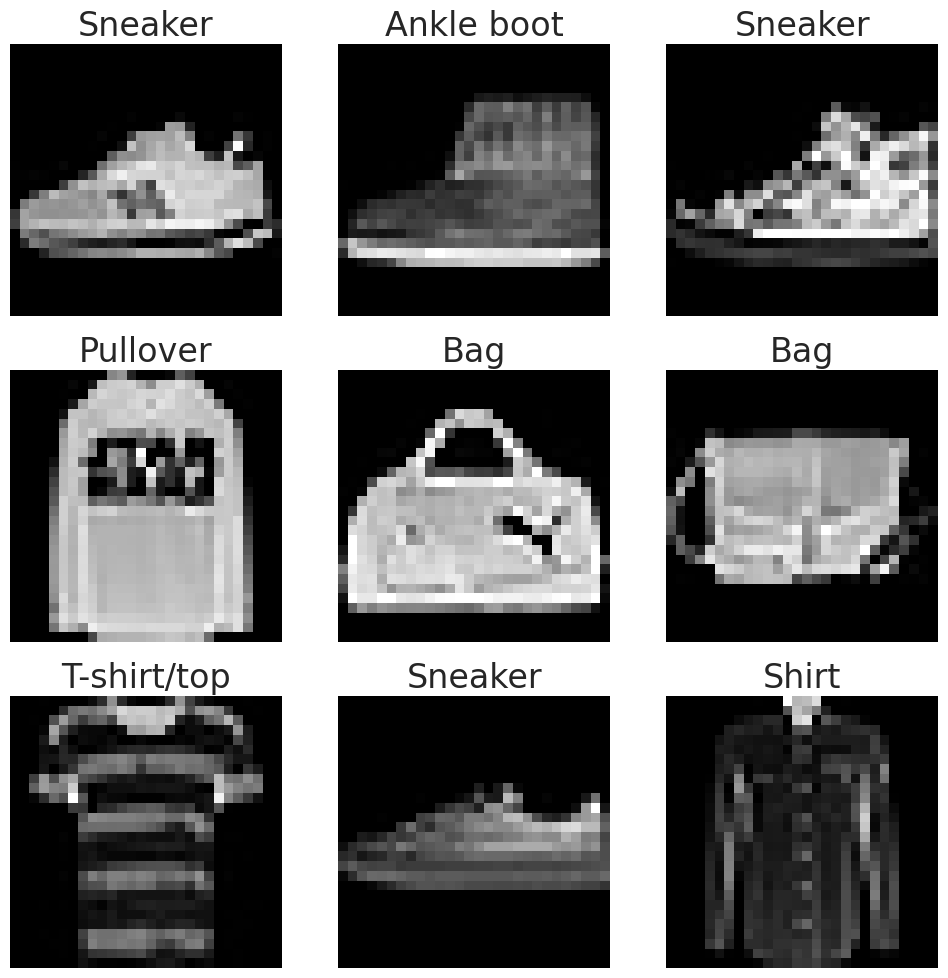

In [32]:
# Visualization

fig, axes = plt.subplots(3, 3, figsize = (12,12))
for row in axes:
    for axe in row:
        index = np.random.randint(60000)
        img = clothing_data.drop('label', axis=1).values[index].reshape(28,28)
        cloths = clothing_data['label'][index]
        axe.imshow(img, cmap='gray')
        axe.set_title(clothing_class[cloths])
        axe.set_axis_off()

## Part II. Classfication
Now use this image data (variable name 'clothing_data') for the further analysis. Split it into training/validation set and perform the classification algorithm. Report the classfication error and top-5 classfication error.

In [34]:
X_fashion = clothing_data.drop(columns = ['label'])
Y_fashion = clothing_data.label

In [35]:
import time
# timer
start_time = time.time()

##############################################################################
### TODO: split your dataset into X and Y then implement your model
### TODO: perform the classification algorithm
### TODO: report the classification error and top-5 classification error.
##############################################################################
# Your codes here
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_fashion = clothing_data.drop(columns=['label'])
Y_fashion = clothing_data['label']

X_train, X_val, y_train, y_val = train_test_split(
    X_fashion, Y_fashion, test_size=0.20, random_state=1, stratify=Y_fashion
)

knn = Pipeline(steps=[
    ("scale", MinMaxScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1))
])

knn.fit(X_train, y_train)

y_pred = knn.predict(X_val)
val_acc = accuracy_score(y_val, y_pred)
val_err = 1.0 - val_acc

proba = knn.predict_proba(X_val)                       
top5_idx = np.argpartition(proba, -5, axis=1)[:, -5:]  
y_true = y_val.to_numpy()
top5_hit = (top5_idx == y_true[:, None]).any(axis=1)   
top5_acc = top5_hit.mean()
top5_err = 1.0 - top5_acc

print(f"Validation classification error (top-1): {val_err:.4f}")
print(f"Validation classification error (top-5): {top5_err:.4f}")

##############################################################################
# END OF YOUR CODE

end_time = time.time()

print(end_time - start_time)

Validation classification error (top-1): 0.1494
Validation classification error (top-5): 0.0321
30.851499319076538


## Part III. Prediction Competition
Now you have these new observations below (variable name `clothing_test`). Try your best to predict the clothing label respectively. Submit your final predicted label and the probability. Your score will depend on your classfication error an top-5 classication error.

In [36]:
clothing_test = pd.read_csv(_DATA_DIR+'clothing_test.csv')
# clothing_test = pd.read_csv('clothing_test.csv')
clothing_test.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,9,8,0,...,103,87,56,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,14,53,99,17,...,0,0,0,0,63,53,31,0,0,0
3,0,0,0,0,0,0,0,0,0,161,...,137,126,140,0,133,224,222,56,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
##############################################################################
### TODO: make your prdictions using your trained model
##############################################################################
X_test = clothing_test.astype("float32")

y_pred       = knn.predict(X_test)           
y_pred_proba = knn.predict_proba(X_test)      

print("y_pred shape:", y_pred.shape)
print("y_pred_proba shape:", y_pred_proba.shape)
#############################################################################
# END OF YOUR CODE

y_pred shape: (10000,)
y_pred_proba shape: (10000, 10)


+ **You need to submit two result files for Problem 4 along with ipynb file.** Please follow the guidance.

+ Make sure your **file name should include your name** in Canvas. 
+ Ex: "**y_pred_Jaehong_Ahn.csv**" and "**y_pred_proba_Jaehong_Ahn.csv**"

In [45]:
##############################################################################
### TODO: Change YourName in the file name to your name in Canvas
##############################################################################

pd.DataFrame(y_pred).to_csv("y_pred_Zhou_Shen.csv", index=False)
pd.DataFrame(y_pred_proba).to_csv("y_pred_proba_Zhou_Shen.csv", index=False)

---

# Problem 5: Return Prediction Competition (20 Points)

In this project, your goal is to predict weekly (5-day) returns on a daily basis using a comprehensive panel dataset with a wide array of features. Keep in mind that some of these features may be redundant or simply noise. Your task is to develop an empirical model that effectively harnesses these features to forecast future returns, while carefully managing the risk of overfitting.

You are encouraged to apply any approach covered in the course to build your model. Your model should be capable of generating predictions for the out-of-sample data provided, which does not include target variables. The out-of-sample prediction performance will be a key evaluation metric.

To assist you, a benchmark example using OLS regressions is provided below to illustrate the expected output format for your predictions. Feel free to explore different predictive methods, focusing on robustness and accuracy.

In [ ]:
import pandas as pd
import statsmodels.api as sm

### Example code: Using all in-sample data and train an OLS model with selected variables.

### Notes:
1. The output predictions on the out-of-sample (OOS) data **must** be in a double-index pandas Series format (see example output below).
2. Due to requirements from the data vendor, the "cusip" index and the feature names have been encrypted. However, this should not interfere with your model development.
3. The OLS example below uses a small number of columns to prevent excessive memory usage on the server, which can lead to the kernel terminating unexpectedly. Make sure to implement a reasonable approach to reduce the number of variables. Consider this a computational constraint commonly encountered in practice.

In [ ]:
ins_data = pd.read_pickle(_DATA_DIR+'ins_data.pkl')
oos_data = pd.read_pickle(_DATA_DIR+'oos_data.pkl')
# ins_data = pd.read_pickle('ins_data.pkl')
# oos_data = pd.read_pickle('oos_data.pkl')

In [ ]:
ins_data

---
## Example

In [ ]:
# vvv Implement your model below vvv
X = ins_data.drop('target', axis=1)  # Features
y = ins_data['target']               # Target variable

In [ ]:
# Define the selected column indices
selected_indices = [0, 2, 4]  # Replace with the desired column indices

# Subset, fill NA, and add a constant to the in-sample data
X_selected = sm.add_constant(X.iloc[:, selected_indices].fillna(0))

# Subset, fill NA, and add a constant to the out-of-sample data
X_oos_selected = sm.add_constant(oos_data.iloc[:, selected_indices].fillna(0))

# Run OLS regression on the selected in-sample features
model = sm.OLS(y, X_selected).fit()

# Make predictions using the out-of-sample data
predictions = model.predict(X_oos_selected)

In [ ]:
predictions

In [ ]:
predictions.to_pickle('D_XIU_predictions.pkl')

---
## Your Prediction Model

In [66]:
import numpy as np
import pandas as pd
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

if 'ins_data' not in globals() or 'oos_data' not in globals():
    ins_data = pd.read_pickle(_DATA_DIR + 'ins_data.pkl')
    oos_data = pd.read_pickle(_DATA_DIR + 'oos_data.pkl')

ins_data = ins_data.copy()
oos_data = oos_data.copy()
for df in (ins_data, oos_data):
    for c in df.columns:
        if c != 'target':
            df[c] = df[c].astype('float32', copy=False)

X_ins = ins_data.drop(columns=['target'])
y_ins = ins_data['target'].astype('float32')

na_ratio = X_ins.isna().mean()
keep_mask_na = (na_ratio <= 0.40)

col_var = X_ins.var(skipna=True)
keep_mask_var = (col_var > 1e-8)

base_keep = keep_mask_na & keep_mask_var
X_screened = X_ins.loc[:, base_keep.index[base_keep]]

corrs = []
for col in X_screened.columns:
    s = X_screened[col]

    m = s.notna() & y_ins.notna()
    if m.sum() >= 50:            
        corrs.append((col, float(np.corrcoef(s[m], y_ins[m])[0,1])))
    else:
        corrs.append((col, np.nan))

corrs = pd.Series({c:v for c,v in corrs}).abs().fillna(0.0)

TOP_K = 300
top_cols = corrs.sort_values(ascending=False).head(TOP_K).index.tolist()

X_ins_sel = X_screened.loc[:, top_cols]

imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler(with_mean=True, with_std=True)

X_ins_imp = imputer.fit_transform(X_ins_sel)
X_ins_std = scaler.fit_transform(X_ins_imp)

alphas = np.logspace(-3, 3, 9)   # 1e-3, ..., 1e3
ridge = RidgeCV(alphas=alphas, cv=3, fit_intercept=True)
ridge.fit(X_ins_std, y_ins.values)

print(f"[Model] RidgeCV chosen alpha = {ridge.alpha_:.4g}")

X_oos = oos_data.loc[:, top_cols].copy()

X_oos_imp = imputer.transform(X_oos)
X_oos_std = scaler.transform(X_oos_imp)

y_oos_pred = ridge.predict(X_oos_std).astype('float32')
predictions = pd.Series(y_oos_pred, index=oos_data.index, name='pred')

print(predictions.head(10))
print("Index type:", type(predictions.index))


[Model] RidgeCV chosen alpha = 1000
date        cusip                   
2019-01-09  0mSIfJXY0AGa4IBstUqVfQ==   -0.001193
            1mSBe5On0AGa4IBstUqVfQ==    0.010675
            0mKHeJ7Q0AGa4IBstUqVfQ==    0.001732
            1W2Bf5Ck0AGa4IBstUqVfQ==   -0.003344
            1mKCcZbZ0AGa4IBstUqVfQ==    0.001562
            0mCEe57T0AGa4IBstUqVfQ==    0.002938
            32eEe5LZ0AGa4IBstUqVfQ==   -0.001678
            1WeIepS30AGa4IBstUqVfQ==   -0.003871
            1mWBeZTQ0AGa4IBstUqVfQ==   -0.004220
            02OCfpCi0AGa4IBstUqVfQ==    0.002593
Name: pred, dtype: float32
Index type: <class 'pandas.core.indexes.multi.MultiIndex'>


##### Instructions: 

+ **You need to submit prediction file along with ipynb file.** Please follow the guidance.
+ **Your model output must follow exactly the same format!** [**shape = (28153,)**]
+ Make sure your **file name should include your name** in Canvas. 
+ Make sure you submit the **YOURFIRSTNAMEINITIAL_YOURLASTNAME_predictions.pkl** file.
+ Ex: "**D_XIU_predictions.csv**"

In [67]:
predictions.to_pickle('Z_Shen_predictions.pkl')